# [Project 4: Implementing Transformer Models for NLP Applications](https://github.com/jcp-tech/Seneca_Class_Notes/blob/master/Semester%202/AIG220%20-%20Deep%20Learning/Projects/Project%204/Project_4.ipynb)

## Introduction

In this project, you will design, implement, and evaluate a Transformer-based neural network (such as BERT or GPT) for a real-world NLP task. Transformers have dramatically improved the performance of NLP tasks by using self-attention mechanisms. You'll gain practical experience fine-tuning pre-trained Transformer models, managing data preprocessing, and clearly evaluating model performance.

You will select one of the provided datasets and corresponding tasks, creating the entire pipeline from dataset preparation through model evaluation.


## Objectives

1. Set up an environment using PyTorch or Tensorlow, Hugging Face's Transformers library, and GPU acceleration.
2. Implement preprocessing pipelines suitable for Transformer models.
3. Choose and load one of the provided datasets.
4. Fine-tune a pre-trained Transformer model for your selected NLP task.
5. Evaluate your model clearly, showing relevant performance metrics and visualizations.
6. Provide detailed answers to the provided assessment questions.

## Dataset

<!-- You are free to choose any dataset for this project! Kaggle would be a good source to look for datasets. Below are some examples: -->
- IMDB Movie Reviews (Sentiment Analysis)
<!-- 
- Yelp Reviews (Multi-class Sentiment Classification)
- Amazon Product Reviews (Sentiment Classification)
- Tweet Emotion Recognition
- News Category Classification
- Question Answering (QA)
-->

## Data Preprocessing Requirements
For all projects, perform the following preprocessing steps:
- Tokenize texts using Hugging Face Tokenizer.
- Perform padding and truncation to create uniform-length inputs.
- Split data into appropriate training, validation, and test sets as applicable.

## Setup and Imports

This section installs and imports all the necessary libraries for the project. This includes libraries for data manipulation, model training, and visualization.

In [ ]:
# pip install scikit-learn transformers kagglehub matplotlib seaborn pandas --upgrade
# pip install transformers[torch] # pip install 'accelerate>=0.26.0'
# pip install "numpy<2" # need numpy==1.26.4 for my GPU configuration, adjust as needed
# pip install torch==2.5.1 # for my GPU configuration, adjust as needed
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import kagglehub, os, re, random, torch, transformers, warnings, json
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
SEED = 42  # Set a seed for reproducibility
# sns.set_style('darkgrid')
random.seed(SEED)                # Sets Python's random module seed for reproducible random operations
np.random.seed(SEED)             # Sets NumPy's random seed for consistent results in NumPy-based randomness
torch.manual_seed(SEED)          # Sets PyTorch's CPU random seed for reproducible weight initialization and shuffling
transformers.set_seed(SEED)      # (Optional) Sets all relevant random seeds in Hugging Face Transformers for full reproducibility
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED) # Sets PyTorch's GPU random seed for reproducibility in CUDA (GPU) computations
  print('CUDA available:', torch.cuda.is_available())
else:
  print('CUDA not available')
warnings.filterwarnings('ignore')

2025-08-04 20:25:04.377528: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-04 20:25:04.377568: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-04 20:25:04.379085: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-04 20:25:04.389985: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-04 20:25:06.552859: W tensorflow/compiler/tf2

CUDA available: True


## Data Loading and Preprocessing

Here, we load the IMDb dataset, clean the text data by removing HTML tags and special characters, and then split it into training, validation, and testing sets.

In [2]:
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print("Path to dataset files:", path)

Path to dataset files: /home/jetauto/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


In [3]:
df = pd.read_csv(os.path.join(path, 'IMDB Dataset.csv'))
display(df)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [6]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'[^a-zA-Z ]', '', text)  # Remove special chars/digits
    text = ' '.join(text.split())  # Normalize whitespace
    return text

df['review'] = df['review'].apply(clean_text)
df['label'] = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

In [7]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print('Train:', train_df.shape)
print('Validation:', val_df.shape)
print('Test:', test_df.shape)

Train: (40000, 3)
Validation: (5000, 3)
Test: (5000, 3)


## BERT Model Setup

This part of the notebook sets up the BERT tokenizer and defines a custom dataset class to prepare the data for the model.

In [ ]:
model_name = 'bert-base-uncased'  # 'distilbert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)

In [9]:
class IMDbDataset(Dataset):
    def __init__(self, reviews, labels, tokenizer, max_len=128):
        self.reviews = reviews
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.reviews)
    def __getitem__(self, idx):
        text = str(self.reviews.iloc[idx])
        label = int(self.labels.iloc[idx])
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [10]:
train_dataset = IMDbDataset(train_df['review'], train_df['label'], tokenizer)
val_dataset = IMDbDataset(val_df['review'], val_df['label'], tokenizer)
test_dataset = IMDbDataset(test_df['review'], test_df['label'], tokenizer)

## Model Training

We define the BERT model for sequence classification, set up the training arguments, and create a `Trainer` instance to fine-tune the model on our dataset.

In [ ]:
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
# print(model)
device

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


device(type='cuda')

In [12]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_dir='./logs',
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    report_to='none'  # Disable wandb or tensorboard logging if not used
)

In [13]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds),
        'recall': recall_score(labels, preds),
        'f1': f1_score(labels, preds)
    }

In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.274700,0.278065,0.887400,0.841623,0.954400,0.894470
2,0.177900,0.307706,0.898800,0.896579,0.901600,0.899083
3,0.111000,0.426930,0.899200,0.887122,0.914800,0.900748


## Visualize Training Results

After training, we plot the training and validation loss, as well as the validation accuracy, to assess the model's learning progress.

In [15]:
# Extract logs from Trainer's state.log_history
train_loss = []
val_loss = []
epochs = []
val_accuracy = []

for log in trainer.state.log_history:
    if 'loss' in log and 'epoch' in log and 'eval_loss' not in log:
        train_loss.append(log['loss'])
        epochs.append(log['epoch'])
    if 'eval_loss' in log:
        val_loss.append(log['eval_loss'])
        val_accuracy.append(log.get('eval_accuracy', None))

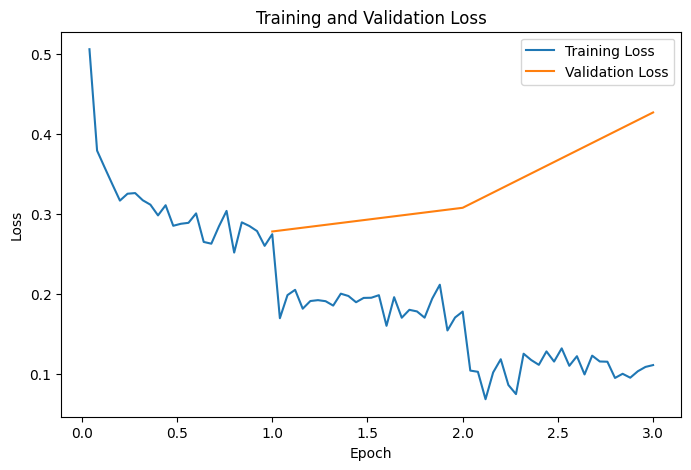

In [16]:
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label='Training Loss')
if val_loss:
    plt.plot(range(1, len(val_loss)+1), val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

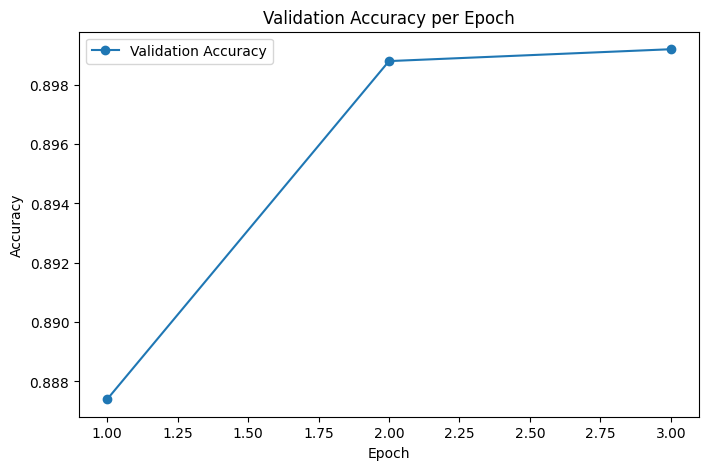

In [17]:
if all(x is not None for x in val_accuracy):
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(val_accuracy)+1), val_accuracy, marker='o', label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy per Epoch')
    plt.legend()
    plt.show()

## Model Evaluation

The model is evaluated on the validation and test sets. We also compute and display a confusion matrix to understand the types of errors the model makes.

In [ ]:
val_results = trainer.evaluate(val_dataset)
print('Validation Results:')
print(json.dumps(val_results, indent=2))

Validation Results:
{
  "eval_loss": 0.2780648469924927,
  "eval_accuracy": 0.8874,
  "eval_precision": 0.8416225749559083,
  "eval_recall": 0.9544,
  "eval_f1": 0.8944704779756326,
  "eval_runtime": 104.7166,
  "eval_samples_per_second": 47.748,
  "eval_steps_per_second": 2.989,
  "epoch": 3.0
}


In [ ]:
results = trainer.evaluate(test_dataset)
print('Test Results:')
print(json.dumps(results, indent=2))

Test Results:
{
  "eval_loss": 0.27349045872688293,
  "eval_accuracy": 0.889,
  "eval_precision": 0.8469496967534784,
  "eval_recall": 0.9496,
  "eval_f1": 0.8953422590986234,
  "eval_runtime": 108.7338,
  "eval_samples_per_second": 45.984,
  "eval_steps_per_second": 2.879,
  "epoch": 3.0
}


In [20]:
predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(-1)
labels = predictions.label_ids

print('Accuracy:', accuracy_score(labels, preds))
print('Precision:', precision_score(labels, preds))
print('Recall:', recall_score(labels, preds))
print('F1 Score:', f1_score(labels, preds))

Accuracy: 0.889
Precision: 0.8469496967534784
Recall: 0.9496
F1 Score: 0.8953422590986234


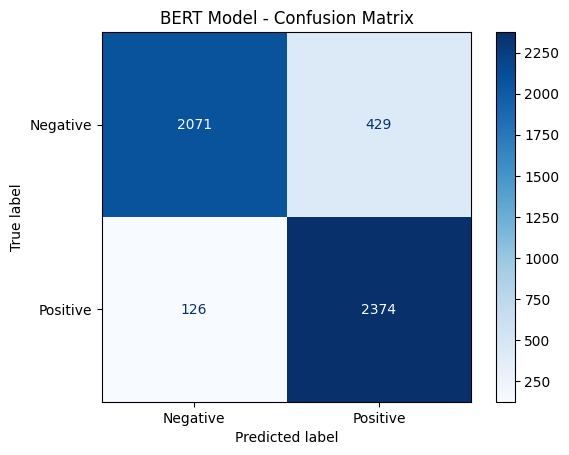

In [21]:
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('BERT Model - Confusion Matrix')
plt.show()

## Analyze Misclassified Examples

We examine some of the reviews that the model misclassified to gain insights into its weaknesses.

In [25]:
misclassified = test_df.loc[preds != test_df['label'].values]
print('Number of misclassified reviews:', len(misclassified), 'out of', len(test_df))
print(misclassified[['review', 'sentiment']].head(10))

Number of misclassified reviews: 555 out of 5000
                                                  review sentiment
25851  Gene Hackman is a former Marine Corps colonel ...  negative
43101  When I saw this movie in the theater when it c...  positive
3260   This is an antiSerb propaganda film made for T...  negative
9046   When I saw that this film was being aired on l...  positive
11282  I can imagine what happened for this film to c...  negative
23424  Hollywood had a long love affair with bogus Ar...  negative
40639  This is what happens when you try to adapt a p...  negative
33858  Michael Feifer writes and directs this fictiti...  negative
16632  Some people have made a point of dissing this ...  negative
30284  This could have been a breakout role for Valer...  negative


## Save the Model

The fine-tuned model and tokenizer are saved to disk for later use.

In [33]:
model.save_pretrained('./bert_sentiment_model/model')
tokenizer.save_pretrained('./bert_sentiment_model/tokenizer')
print('Model and tokenizer saved to ./bert_sentiment_model')

Model and tokenizer saved to ./bert_sentiment_model


## Conceptual Q\&A

### 1. What is a Transformer model, and how does it differ fundamentally from recurrent neural networks (RNNs)?

A Transformer is a neural network architecture that relies on self-attention mechanisms instead of recurrence. Unlike RNNs, which process input sequences sequentially (making them slow and prone to forgetting earlier context), Transformers process all input tokens in parallel and can directly attend to any part of the sequence, enabling better learning of long-range dependencies and faster training.

### 2. Explain the concept of self-attention and why it significantly improves NLP tasks.

Self-attention allows each word in a sentence to weigh its relationships to every other word, regardless of their distance in the text. This makes it possible to capture context and subtle dependencies that RNNs often miss, greatly improving performance on NLP tasks such as sentiment analysis, translation, and summarization.

### 3. Discuss why fine-tuning pretrained Transformer models is effective compared to training from scratch.

Fine-tuning starts from a model (like BERT) already trained on massive, diverse text corpora. This model has learned language structures, grammar, and world knowledge. By adapting (fine-tuning) it on your task-specific data (movie review sentiment), you get better results with less data and compute than training a model from scratch—often achieving state-of-the-art performance quickly.

### 4. What is the difference between BERT and GPT models? Key design differences and typical use cases.

* **BERT:** Bidirectional; learns context from both left and right of each word. Used mainly for understanding tasks (classification, question answering).
* **GPT:** Unidirectional (left-to-right); designed for generating coherent text sequences. Best for text generation, completion, and conversational agents.
* **Summary:** BERT for *understanding*, GPT for *generating*.

### 5. Explain positional encoding in Transformer models and its importance.

Since Transformers process tokens in parallel, they lack inherent order information. Positional encoding injects sequence order into the input, letting the model understand word order—critical for meaningful language processing (e.g., “The dog chased the cat” vs. “The cat chased the dog”).

### 6. What are some common evaluation metrics used for your chosen NLP task, and why?

* **Accuracy:** Overall fraction of correct predictions.
* **Precision:** Correctly predicted positives / all predicted positives (important to avoid false positives).
* **Recall:** Correctly predicted positives / all actual positives (important to avoid false negatives).
* **F1 Score:** Harmonic mean of precision and recall (balances both).
* These metrics give a comprehensive view of model performance, especially with imbalanced classes.

### 7. Discuss potential drawbacks or limitations of Transformer models (e.g., computational complexity, data requirements).

Transformers require significant computational resources (especially with long sequences, due to quadratic memory/time complexity). They need large datasets for pretraining and may overfit on small task-specific datasets. In deployment, they can be too heavy for edge devices or latency-sensitive applications.

### 8. How does tokenization impact Transformer model performance, and what considerations are important during data preprocessing?

Tokenization breaks input text into subword units for the model. Using the correct tokenizer (matching the pretrained model, e.g., BERT’s WordPiece) preserves meaning and consistency. Bad tokenization can cause information loss, poor handling of rare words, and degraded performance. Preprocessing should also handle casing, punctuation, and special tokens.

### 9. Provide at least two examples of real-world applications using Transformers outside of your chosen task.

* **Machine Translation** (e.g., Google Translate).
* **Text Summarization** (legal/medical documents).
* **Other:** Code generation (GitHub Copilot), chatbots, information retrieval, etc.

### 10. What future directions or improvements could further enhance Transformer models?

* Reducing computational/memory costs (e.g., with sparse attention or efficient architectures like Longformer, MobileBERT).
* More efficient and robust tokenization.
* Multimodal Transformers (combining text, vision, audio).
* Better interpretability and robustness to adversarial attacks.
* Training on smaller, more diverse data with less supervision.

---
### Submission
Submit a link to your completed Jupyter Notebook (e.g. Google Colab) with all the cells executed, and answers to the assessment questions included at the end of the notebook.